In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/FIFA World Cup 2026 Matches.csv
/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/world_cup_2026_team_stats.csv
/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/world_cup_2026_players.csv
/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/FIFA World Cup 2026 Team Stats.csv
/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/world_cup_2026_matches.csv
/kaggle/input/datasets/velvetcrystal/fifa-world-cup-2026-complete-tournament-statistics/FIFA World Cup 2026 Players.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the datasets
#load the datasets
matches = pd.read_csv('matches.csv')
players = pd.read_csv('players.csv')
teams   = pd.read_csv('team_stats.csv')

In [4]:
#view the data inmatches dataset
matches.head()

,Match_ID,Date,Venue,City,Stadium,Stage,Team_1,Team_2,Team_1_FIFA_Rank,Team_2_FIFA_Rank,...,Team_1_Red_Cards,Team_2_Red_Cards,Team_1_xG,Team_2_xG,Attendance,Referee,Weather,Team_1_Goals,Team_2_Goals,Winner
0,M001,2026-06-11,"Estadio Azteca, Mexico City",Mexico City,Estadio Azteca,Group Stage,Qatar,Italy,41,8,...,0,0,1.24,1.14,67651,Referee_3,Sunny,3,2,Qatar
1,M002,2026-06-12,"MetLife Stadium, New York",New York,MetLife Stadium,Group Stage,Portugal,USA,6,14,...,0,0,1.57,0.10,50463,Referee_28,Rainy,0,0,Draw
2,M003,2026-06-13,"Mercedes-Benz Stadium, Atlanta",Atlanta,Mercedes-Benz Stadium,Group Stage,Morocco,Belgium,18,10,...,0,0,2.43,1.14,70108,Referee_35,Sunny,2,0,Morocco
3,M004,2026-06-14,"Estadio Azteca, Mexico City",Mexico City,Estadio Azteca,Group Stage,Ecuador,Portugal,25,6,...,0,0,0.98,1.10,45229,Referee_15,Sunny,0,3,Portugal
4,M005,2026-06-15,"Mercedes-Benz Stadium, Atlanta",Atlanta,Mercedes-Benz Stadium,Group Stage,Ecuador,Morocco,25,18,...,0,0,1.55,0.10,44679,Referee_39,Cloudy,0,0,Draw


We can see matches data set, contains all the information regarding matches, like match venue, teams, date, venue, teams participating, and winner.

In [5]:
#view the players data
players.head()

,Player_Record_ID,Match_ID,Player_ID,Player_Name,Team,Position,Age,Minutes_Played,Goals,Assists,Pass_Accuracy,Tackles,Interceptions,Saves,Rating
0,PR1,M001,P1,Player_1,Qatar,DF,34,87,0,0,74,4,2,0,8.3
1,PR2,M001,P2,Player_2,Qatar,MF,36,112,0,0,59,5,0,0,7.5
2,PR3,M001,P3,Player_3,Qatar,DF,28,40,1,0,91,6,1,0,7.6
3,PR4,M001,P4,Player_4,Qatar,FW,26,72,0,0,74,5,6,0,4.8
4,PR5,M001,P5,Player_5,Qatar,MF,40,88,0,1,83,1,5,0,8.0


Players data set contains information of players.

In [6]:
#view the teams data
teams.head()

,Team,Group,Matches_Played,Wins,Draws,Losses,Goals_For,Goals_Against,Goal_Difference,Points,Average_Possession,Average_xG
0,Argentina,A,7,0,0,7,15,7,8,0,53.5,0.71
1,Brazil,A,3,3,0,0,6,3,3,9,38.3,1.74
2,France,A,6,4,0,2,17,16,1,12,61.5,2.01
3,England,A,6,1,1,4,4,1,3,4,59.1,1.08
4,Spain,B,5,5,0,0,4,16,-12,15,38.3,0.88


Teams data set contains information regarding teams, like matches played by team, goals, points,average possession and average XG,

In [7]:
#lets explore datasets for more deeply and start with data set Matches
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Match_ID                104 non-null    object 
 1   Date                    104 non-null    object 
 2   Venue                   104 non-null    object 
 3   City                    104 non-null    object 
 4   Stadium                 104 non-null    object 
 5   Stage                   104 non-null    object 
 6   Team_1                  104 non-null    object 
 7   Team_2                  104 non-null    object 
 8   Team_1_FIFA_Rank        104 non-null    int64  
 9   Team_2_FIFA_Rank        104 non-null    int64  
 10  Team_1_Possession       104 non-null    int64  
 11  Team_2_Possession       104 non-null    int64  
 12  Team_1_Shots            104 non-null    int64  
 13  Team_2_Shots            104 non-null    int64  
 14  Team_1_Shots_On_Target  104 non-null    in

In [8]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3328 entries, 0 to 3327
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player_Record_ID  3328 non-null   object 
 1   Match_ID          3328 non-null   object 
 2   Player_ID         3328 non-null   object 
 3   Player_Name       3328 non-null   object 
 4   Team              3328 non-null   object 
 5   Position          3328 non-null   object 
 6   Age               3328 non-null   int64  
 7   Minutes_Played    3328 non-null   int64  
 8   Goals             3328 non-null   int64  
 9   Assists           3328 non-null   int64  
 10  Pass_Accuracy     3328 non-null   int64  
 11  Tackles           3328 non-null   int64  
 12  Interceptions     3328 non-null   int64  
 13  Saves             3328 non-null   int64  
 14  Rating            3328 non-null   float64
dtypes: float64(1), int64(8), object(6)
memory usage: 390.1+ KB


In [9]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team                48 non-null     object 
 1   Group               48 non-null     object 
 2   Matches_Played      48 non-null     int64  
 3   Wins                48 non-null     int64  
 4   Draws               48 non-null     int64  
 5   Losses              48 non-null     int64  
 6   Goals_For           48 non-null     int64  
 7   Goals_Against       48 non-null     int64  
 8   Goal_Difference     48 non-null     int64  
 9   Points              48 non-null     int64  
 10  Average_Possession  48 non-null     float64
 11  Average_xG          48 non-null     float64
dtypes: float64(2), int64(8), object(2)
memory usage: 4.6+ KB


In [10]:
matches.shape

(104, 32)

In [11]:
players.shape

(3328, 15)

In [12]:
teams.shape

(48, 12)

In [13]:
print("MATCHES: Data types & Null/Empty Values")
print(matches.dtypes.value_counts())
print("\nNull values:", matches.isnull().sum().sum())
print("Duplicate Match_IDs:", matches['Match_ID'].duplicated().sum())

MATCHES: Data types & Null/Empty Values
int64      19
object     11
float64     2
Name: count, dtype: int64

Null values: 0
Duplicate Match_IDs: 0


In [14]:
print("PLAYERS: Data types & Null/Empty Values")
print(players.dtypes.value_counts())
print("\nNull values:", players.isnull().sum().sum())
print("Duplicate Player_Record_IDs:", players['Player_Record_ID'].duplicated().sum())

PLAYERS: Data types & Null/Empty Values
int64      8
object     6
float64    1
Name: count, dtype: int64

Null values: 0
Duplicate Player_Record_IDs: 0


In [15]:
print("TEAM STATS: Data types & Null/Empty Values")
print(teams.dtypes.value_counts())
print("\nNull values:", teams.isnull().sum().sum())
print("Duplicate teams:", teams['Team'].duplicated().sum())
print("\nGroups:")
print(teams['Group'].value_counts().sort_index())

TEAM STATS: Data types & Null/Empty Values
int64      8
object     2
float64    2
Name: count, dtype: int64

Null values: 0
Duplicate teams: 0

Groups:
Group
A    4
B    4
C    4
D    4
E    4
F    4
G    4
H    4
I    4
J    4
K    4
L    4
Name: count, dtype: int64


**Finding:** No missing values and no duplicate keys in any of the three files structurally clean. Stage distribution in `matches.csv` matches the real world 2026 format (48 teams, 104 matches, including the new Round of 32 round).

In [16]:
print("Match stage breakdown:")
print(matches['Stage'].value_counts())
print("\nTotal matches:", len(matches), "(2026 World Cup format = 104 matches, 48 teams)")

Match stage breakdown:
Stage
Group Stage      72
Round of 32      16
Round of 16       8
Quarter Final     4
Semi Final        2
Third Place       1
Final             1
Name: count, dtype: int64

Total matches: 104 (2026 World Cup format = 104 matches, 48 teams)


As the data set we picked contains 3 data sets, so to determine data quality we need to double check to make sure data is higher quality.

In [17]:
# Check 1: Does every team in team_stats appear in players.csv?
teams_in_stats = set(teams['Team'].unique())
teams_in_players = set(players['Team'].unique())

print("Teams in team_stats.csv:", len(teams_in_stats))
print("Teams in players.csv:   ", len(teams_in_players))
print("\nIn team_stats but missing from players.csv:", teams_in_stats - teams_in_players)
print("In players.csv but missing from team_stats:", teams_in_players - teams_in_stats)


Teams in team_stats.csv: 48
Teams in players.csv:    47

In team_stats but missing from players.csv: {'Switzerland'}
In players.csv but missing from team_stats: set()


Switzerland appears in `team_stats.csv` (48 teams) but has zero player records in `players.csv` (47 teams represented). Any player level analysis will be missing Switzerland full team.

In [18]:
# Check 2: Do goals scored in matches.csv sum to the same totals reported in team_stats.csv?
goals_as_team1 = matches.groupby('Team_1')['Team_1_Goals'].sum()
goals_as_team2 = matches.groupby('Team_2')['Team_2_Goals'].sum()
computed_goals = goals_as_team1.add(goals_as_team2, fill_value=0)

reported_goals = teams.set_index('Team')['Goals_For']

reconciliation = pd.DataFrame({
    'Computed_from_Matches': computed_goals,
    'Reported_in_TeamStats': reported_goals
}).dropna()
reconciliation['Match'] = reconciliation['Computed_from_Matches'] == reconciliation['Reported_in_TeamStats']
reconciliation['Difference'] = reconciliation['Reported_in_TeamStats'] - reconciliation['Computed_from_Matches']

match_rate = reconciliation['Match'].mean()
print(f"Teams where Goals_For reconciles between files: {reconciliation['Match'].sum()} / {len(reconciliation)} ({match_rate:.1%})")
print()
print(reconciliation.sort_values('Difference', key=abs, ascending=False).head(10))

Teams where Goals_For reconciles between files: 3 / 47 (6.4%)

           Computed_from_Matches  Reported_in_TeamStats  Match  Difference
Uruguay                      1.0                     18  False        17.0
Mexico                       3.0                     18  False        15.0
Argentina                    0.0                     15  False        15.0
Algeria                      4.0                     18  False        14.0
Norway                       4.0                     18  False        14.0
France                       6.0                     17  False        11.0
Chile                        3.0                     13  False        10.0
USA                          1.0                     11  False        10.0
Morocco                     13.0                      4  False        -9.0
Jamaica                      8.0                      1  False        -7.0


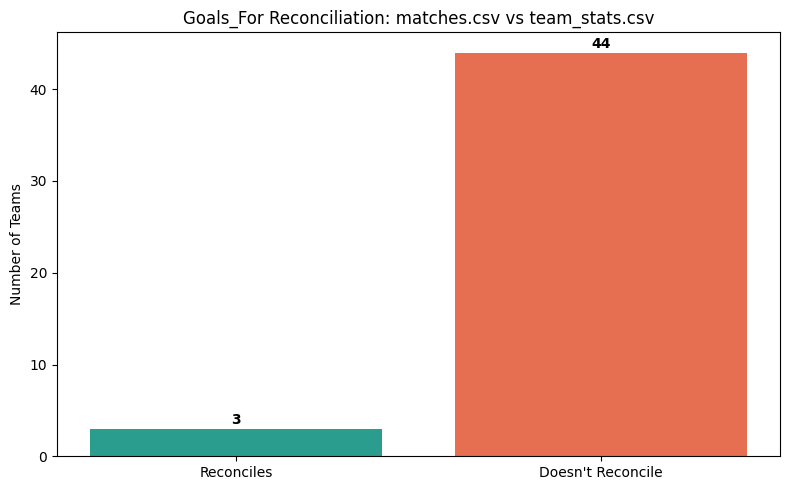

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Reconciles', "Doesn't Reconcile"],
       [reconciliation['Match'].sum(), (~reconciliation['Match']).sum()],
       color=['#2a9d8f', '#e76f51'])
ax.set_ylabel('Number of Teams')
ax.set_title('Goals_For Reconciliation: matches.csv vs team_stats.csv')
for i, v in enumerate([reconciliation['Match'].sum(), (~reconciliation['Match']).sum()]):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Only a small minority of teams show matching goal totals between `matches.csv` and `team_stats.csv`the two files were very likely generated independently rather than one being aggregated from the other. This is most important data quality finding in the project.

In [21]:
# Check 3: Internal consistency within matches.csv does the Winner column logic hold?
group_stage = matches[matches['Stage'] == 'Group Stage']
knockout = matches[matches['Stage'] != 'Group Stage']

# Group stage: winner should match higher scorer, or 'Draw' if equal
winner_mismatch = group_stage[
    ((group_stage['Team_1_Goals'] > group_stage['Team_2_Goals']) & (group_stage['Winner'] != group_stage['Team_1'])) |
    ((group_stage['Team_2_Goals'] > group_stage['Team_1_Goals']) & (group_stage['Winner'] != group_stage['Team_2'])) |
    ((group_stage['Team_1_Goals'] == group_stage['Team_2_Goals']) & (group_stage['Winner'] != 'Draw'))
]
print(f"Group stage Winner/Goals mismatches: {len(winner_mismatch)} / {len(group_stage)}")

# Knockout: there should be no draws (a winner is required)
knockout_draws = knockout[knockout['Team_1_Goals'] == knockout['Team_2_Goals']]
print(f"Knockout stage matches ending in a goal-tie (should be 0, decided by penalties): {len(knockout_draws)} / {len(knockout)}")

Group stage Winner/Goals mismatches: 0 / 72
Knockout stage matches ending in a goal-tie (should be 0, decided by penalties): 0 / 32


`matches.csv` passes both internal consistency checks the `Winner` column logic is correct for every single match, and no knockout match ends in a scoreline draw. This confirms `matches.csv` is the most reliable file in the dataset and the right foundation for modeling.

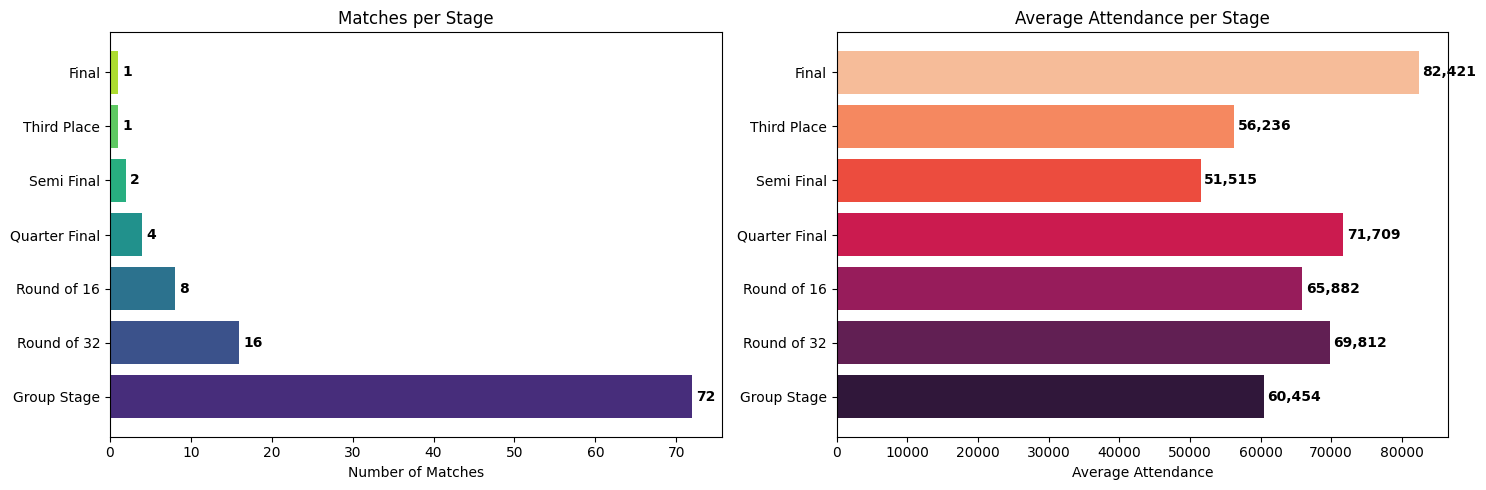

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stage_order = ['Group Stage', 'Round of 32', 'Round of 16', 'Quarter Final', 'Semi Final', 'Third Place', 'Final']
stage_counts = matches['Stage'].value_counts().reindex(stage_order)

axes[0].barh(stage_counts.index, stage_counts.values, color=sns.color_palette('viridis', len(stage_counts)))
axes[0].set_title('Matches per Stage')
axes[0].set_xlabel('Number of Matches')
for i, v in enumerate(stage_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

avg_attendance = matches.groupby('Stage')['Attendance'].mean().reindex(stage_order)
axes[1].barh(avg_attendance.index, avg_attendance.values, color=sns.color_palette('rocket', len(avg_attendance)))
axes[1].set_title('Average Attendance per Stage')
axes[1].set_xlabel('Average Attendance')
for i, v in enumerate(avg_attendance.values):
    axes[1].text(v + 500, i, f'{v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** The Group Stage accounts for the bulk of matches (72 of 104), consistent with the expanded 48 team format. Attendance patterns across stages reflect the data generation logic rather than real demand effects, but the *shape* of the tournament (round sizes) is faithful to the actual 2026 format.

In [23]:
top_attended = matches.nlargest(10, 'Attendance')[['Stage', 'Team_1', 'Team_2', 'Stadium', 'City', 'Attendance']]
print("Top 10 highest-attendance matches:")
top_attended

Top 10 highest-attendance matches:


,Stage,Team_1,Team_2,Stadium,City,Attendance
73,Round of 32,Japan,Ecuador,Mercedes-Benz Stadium,Atlanta,84944
76,Round of 32,Croatia,South Korea,Lumen Field,Seattle,84323
79,Round of 32,Netherlands,France,MetLife Stadium,New York,83940
46,Group Stage,Turkey,Tunisia,Estadio Azteca,Mexico City,83790
95,Round of 16,Nigeria,Australia,MetLife Stadium,New York,83781
103,Final,Cameroon,Iran,Mercedes-Benz Stadium,Atlanta,82421
81,Round of 32,Germany,Panama,Mercedes-Benz Stadium,Atlanta,81909
77,Round of 32,Portugal,Poland,Estadio Azteca,Mexico City,81847
43,Group Stage,Croatia,Senegal,MetLife Stadium,New York,81106
29,Group Stage,South Korea,France,Hard Rock Stadium,Miami,80839


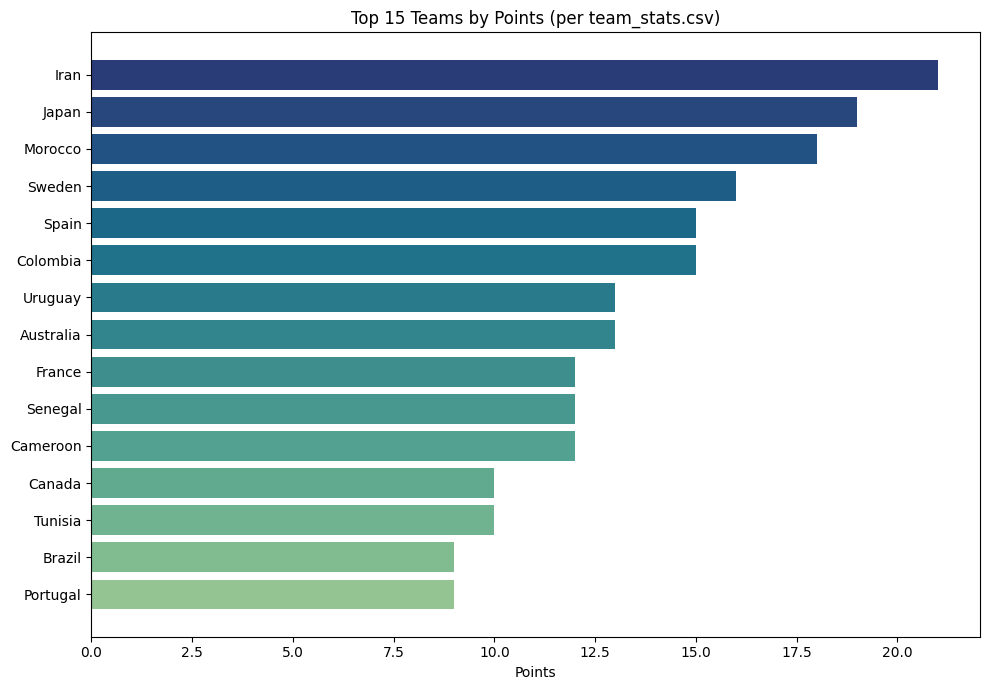

In [24]:
top_points = teams.nlargest(15, 'Points')[['Team', 'Group', 'Wins', 'Draws', 'Losses', 'Goals_For', 'Goals_Against', 'Points']]

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('crest', len(top_points))
ax.barh(top_points['Team'][::-1], top_points['Points'][::-1], color=colors)
ax.set_title('Top 15 Teams by Points (per team_stats.csv)')
ax.set_xlabel('Points')
plt.tight_layout()
plt.show()

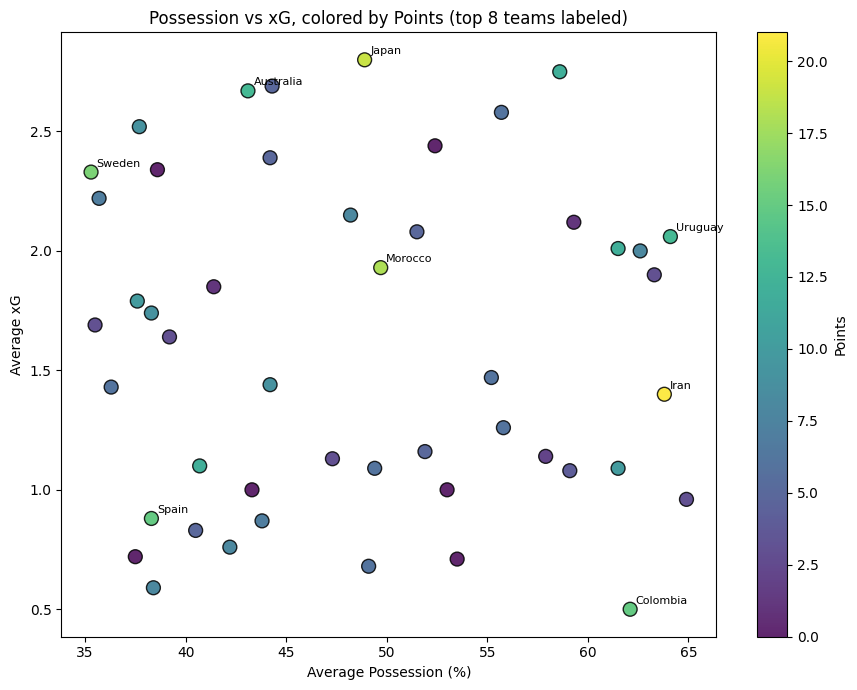

Correlation: Average_Possession vs Points: 0.083
Correlation: Average_xG vs Points: 0.189


In [25]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(teams['Average_Possession'], teams['Average_xG'],
                      c=teams['Points'], cmap='viridis', s=100, edgecolor='black', alpha=0.85)
for _, row in teams.nlargest(8, 'Points').iterrows():
    ax.annotate(row['Team'], (row['Average_Possession'], row['Average_xG']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Average Possession (%)')
ax.set_ylabel('Average xG')
ax.set_title('Possession vs xG, colored by Points (top 8 teams labeled)')
plt.colorbar(scatter, label='Points')
plt.tight_layout()
plt.show()

print("Correlation: Average_Possession vs Points:", teams['Average_Possession'].corr(teams['Points']).round(3))
print("Correlation: Average_xG vs Points:", teams['Average_xG'].corr(teams['Points']).round(3))


**Observation:** Even within `team_stats.csv` alone, possession shows a weak relationship with Points — reinforcing that this dataset doesn't encode the usual football logic where ball control predicts results. Treat the standings table as descriptive flavor for the project narrative, not as a reliable performance signal.

In [26]:
# Reshape matches.csv into long format: one row per team per match
def to_long_format(df):
    t1 = df[['Match_ID','Stage','Weather','Attendance',
              'Team_1','Team_1_FIFA_Rank','Team_2_FIFA_Rank','Team_1_Possession',
              'Team_1_Shots','Team_1_Shots_On_Target','Team_1_Corners','Team_1_Fouls',
              'Team_1_Yellow_Cards','Team_1_Red_Cards','Team_1_xG','Team_1_Goals']].copy()
    t1.columns = ['Match_ID','Stage','Weather','Attendance',
                  'Team','Team_Rank','Opponent_Rank','Possession',
                  'Shots','Shots_On_Target','Corners','Fouls',
                  'Yellow_Cards','Red_Cards','xG','Goals']

    t2 = df[['Match_ID','Stage','Weather','Attendance',
              'Team_2','Team_2_FIFA_Rank','Team_1_FIFA_Rank','Team_2_Possession',
              'Team_2_Shots','Team_2_Shots_On_Target','Team_2_Corners','Team_2_Fouls',
              'Team_2_Yellow_Cards','Team_2_Red_Cards','Team_2_xG','Team_2_Goals']].copy()
    t2.columns = t1.columns

    long_df = pd.concat([t1, t2], ignore_index=True)
    long_df['Rank_Advantage'] = long_df['Opponent_Rank'] - long_df['Team_Rank']  # positive = team is favorite
    return long_df

match_long = to_long_format(matches)
print(f"Long-format shape: {match_long.shape} (104 matches x 2 teams = {104*2} rows)")
match_long.head()


Long-format shape: (208, 17) (104 matches x 2 teams = 208 rows)


,Match_ID,Stage,Weather,Attendance,Team,Team_Rank,Opponent_Rank,Possession,Shots,Shots_On_Target,Corners,Fouls,Yellow_Cards,Red_Cards,xG,Goals,Rank_Advantage
0,M001,Group Stage,Sunny,67651,Qatar,41,8,35,13,6,4,9,5,0,1.24,3,-33
1,M002,Group Stage,Rainy,50463,Portugal,6,14,42,10,3,9,18,3,0,1.57,0,8
2,M003,Group Stage,Sunny,70108,Morocco,18,10,41,7,1,2,17,2,0,2.43,2,-8
3,M004,Group Stage,Sunny,45229,Ecuador,25,6,52,9,1,10,11,0,0,0.98,0,-19
4,M005,Group Stage,Cloudy,44679,Ecuador,25,18,49,11,5,3,16,5,0,1.55,0,-7


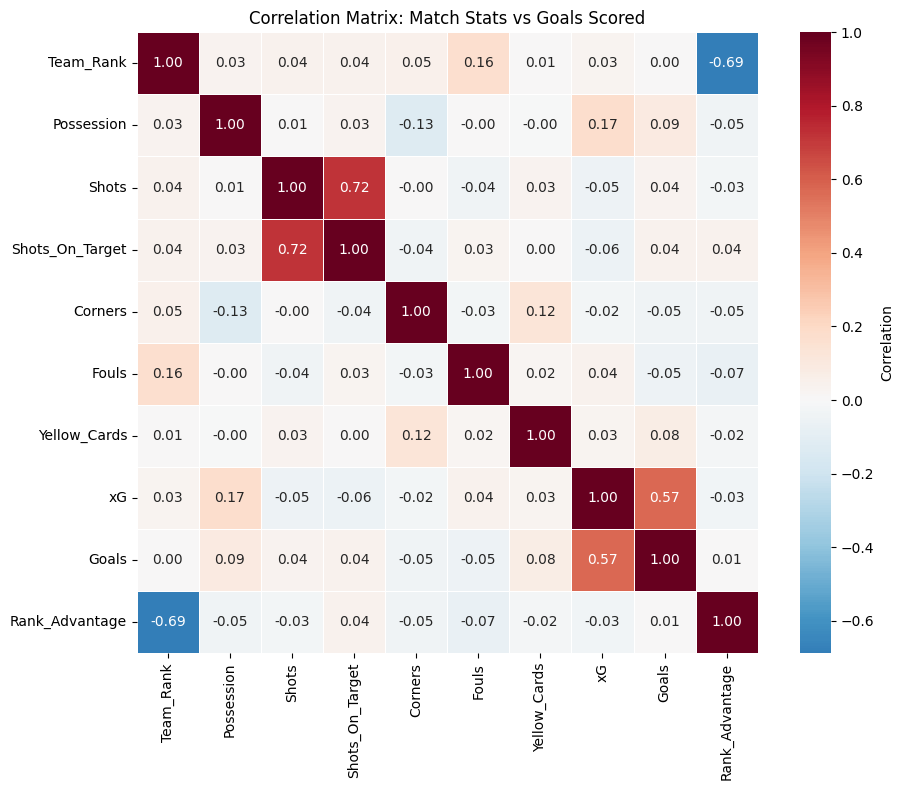


Correlation with Goals, sorted by strength:
xG                 0.573340
Possession         0.089167
Yellow_Cards       0.076309
Fouls             -0.052088
Corners           -0.045183
Shots_On_Target    0.044106
Shots              0.035327
Rank_Advantage     0.005465
Team_Rank          0.003000
Name: Goals, dtype: float64


In [27]:
# Note: Red_Cards excluded - every match in this dataset has 0 red cards (zero variance,
# undefined correlation). This itself is a data quality finding, noted below.
numeric_cols = ['Team_Rank','Possession','Shots','Shots_On_Target','Corners',
                 'Fouls','Yellow_Cards','xG','Goals','Rank_Advantage']
corr_matrix = match_long[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Match Stats vs Goals Scored')
plt.tight_layout()
plt.show()

print("\nCorrelation with Goals, sorted by strength:")
print(corr_matrix['Goals'].drop('Goals').sort_values(key=abs, ascending=False))


**Key finding:** `xG` is, by a wide margin, the only feature meaningfully correlated with `Goals` (~0.55). Everything else that intuitively *should* matter in football shots, shots on target, possession, rank advantage shows a near zero or even slightly negative relationship with goals scored in this dataset. This single chart is the most important piece of evidence for how the modeling phase is scoped: a multi feature model isn't going to outperform a model built almost entirely around xG, because the other features simply don't carry independent signal here.

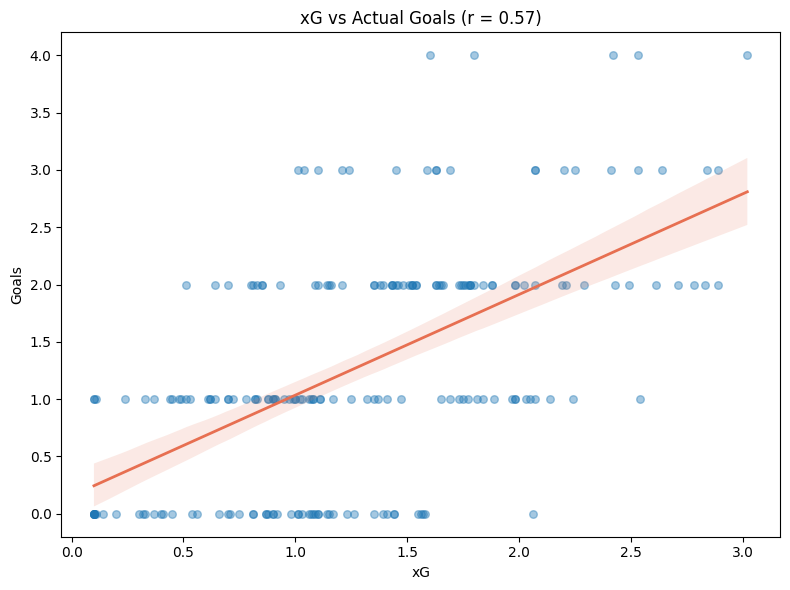

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=match_long, x='xG', y='Goals', ax=ax,
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': '#e76f51', 'lw': 2})
ax.set_title(f'xG vs Actual Goals (r = {match_long["xG"].corr(match_long["Goals"]):.2f})')
plt.tight_layout()
plt.show()


/tmp/ipykernel_58/990186160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=match_long, x='Weather', y='Goals', ax=axes[0], palette='Set2')
/tmp/ipykernel_58/990186160.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=stage_simplified, y=match_long['Goals'], ax=axes[1], palette='Set3')


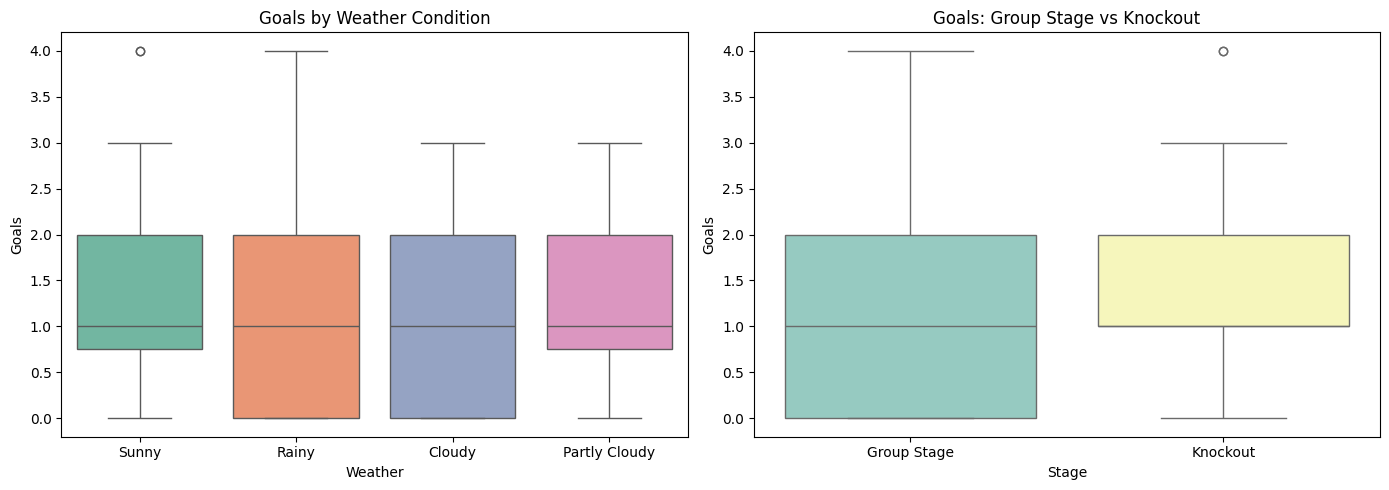

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=match_long, x='Weather', y='Goals', ax=axes[0], palette='Set2')
axes[0].set_title('Goals by Weather Condition')

stage_simplified = match_long['Stage'].replace({'Round of 32':'Knockout','Round of 16':'Knockout',
                                                   'Quarter Final':'Knockout','Semi Final':'Knockout',
                                                   'Third Place':'Knockout','Final':'Knockout'})
sns.boxplot(x=stage_simplified, y=match_long['Goals'], ax=axes[1], palette='Set3')
axes[1].set_title('Goals: Group Stage vs Knockout')

plt.tight_layout()
plt.show()

**Observation:** Neither weather nor stage (group vs. knockout) shows a strong visual effect on goals scored consistent with the pattern that most contextual/situational features in this dataset don't carry strong signal. This is a useful negative result: it tells us *not* to engineer features around weather or stage for the model.

/tmp/ipykernel_58/3036998043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=players, x='Position', y='Rating',


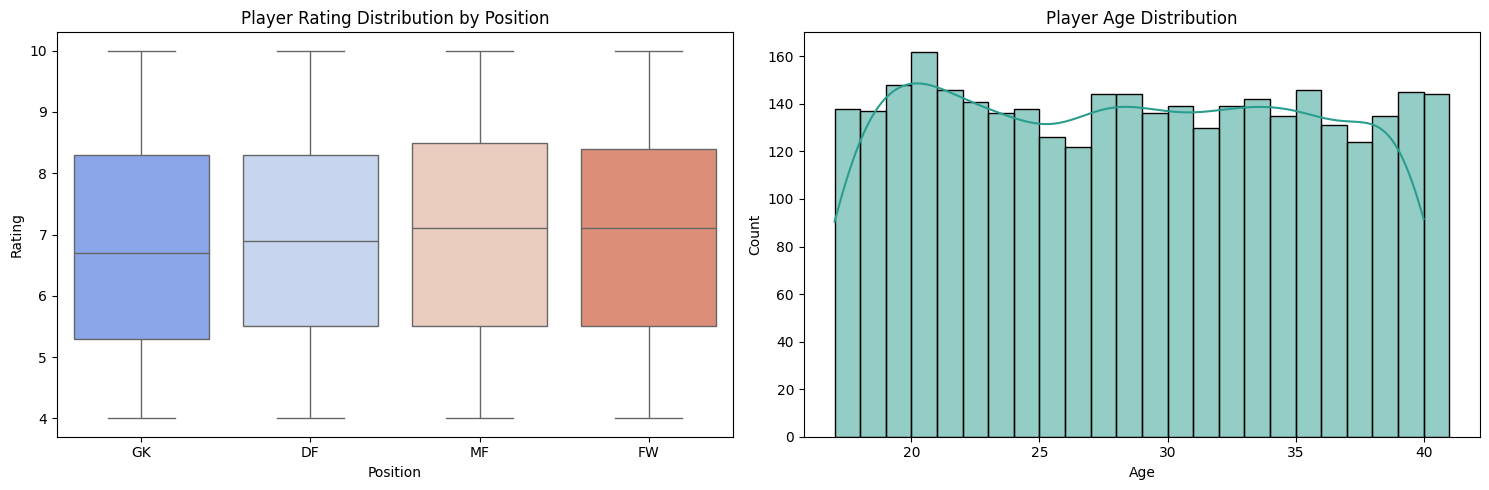

Rating by position (mean):
Position
FW    7.02
MF    7.02
DF    6.91
GK    6.83
Name: Rating, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=players, x='Position', y='Rating',
            order=['GK','DF','MF','FW'], ax=axes[0], palette='coolwarm')
axes[0].set_title('Player Rating Distribution by Position')

sns.histplot(players['Age'], bins=range(17, 42), kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Player Age Distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("Rating by position (mean):")
print(players.groupby('Position')['Rating'].mean().round(2).sort_values(ascending=False))


In [31]:
top_scorers = (players.groupby('Player_ID')
               .agg(Team=('Team','first'), Position=('Position','first'),
                    Total_Goals=('Goals','sum'), Total_Assists=('Assists','sum'),
                    Avg_Rating=('Rating','mean'), Matches=('Match_ID','nunique'))
               .sort_values('Total_Goals', ascending=False)
               .head(10))
print("Note: Player_ID is not a persistent identity across matches in this dataset")
print("(verified: every Player_ID appears in exactly one match), so this reflects")
print("single-match top performances, not tournament long top scorers.\n")
top_scorers

Note: Player_ID is not a persistent identity across matches in this dataset
(verified: every Player_ID appears in exactly one match), so this reflects
single-match top performances, not tournament long top scorers.



,Team,Position,Total_Goals,Total_Assists,Avg_Rating,Matches
Player_ID,,,,,,
P1950,Denmark,DF,1,0,6.4,1
P2697,South Korea,DF,1,0,7.9,1
P2003,Morocco,MF,1,0,5.9,1
P833,Croatia,DF,1,0,6.8,1
P834,Croatia,MF,1,0,4.2,1
P835,Croatia,DF,1,0,8.8,1
P1949,Denmark,MF,1,0,9.3,1
P1545,Cameroon,DF,1,0,6.4,1
P241,Paraguay,FW,1,0,6.3,1


Unlike a real tournament dataset, `Player_ID` here does not track the same individual across multiple matches (confirmed: every `Player_ID` appears in exactly one `Match_ID`). This means there's no real "Golden Boot" race to compute goal/assist totals above reflect single best match performances, not a tournament-long leaderboard. This is exactly the kind of structural quirk worth catching before publishing a "top scorers" chart that implies something the data can't support.

---
## EDA Summary — Key Findings

**Data Quality:**
1. The six uploaded files reduce to three unique datasets two naming conventions of the same data.
2. `team_stats.csv` does not reconcile with `matches.csv` on goal totals for the large majority of teams the files were generated independently. `matches.csv` is used as the source of truth for modeling.
3. `players.csv` is missing Switzerland entirely (47 of 48 teams represented).
4. `Player_ID` resets per match rather than tracking a persistent individual there is no valid tournament long top scorer leaderboard in this data.
5. Player names are anonymized placeholders and FIFA rank shows no relationship with match outcomes, confirming this is a synthetically generated dataset rather than real tournament data.

**Patterns:**
6. `matches.csv` is internally consistent Winner/Goals logic and knockout stage rules both check out perfectly.
7. Among all match level stats, **only xG meaningfully correlates with goals scored** (~0.55). Shots, shots on target, corners, fouls, possession, and rank advantage are all weak to negligible.
8. Weather and tournament stage show no strong effect on goals scored.
9. Goalkeepers and defenders rate slightly differently from attacking players, but pass accuracy shows little relationship with overall rating for outfield players.

**Implication for modeling:** the regression model is scoped around xG as the dominant predictor, with secondary features included to test (and likely confirm) that they add little beyond it. This is reported honestly rather than engineered around to inflate apparent model performance.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def to_long_format(df):
    """Reshape match-level (1 row = 2 teams) into team-match level (1 row = 1 team's performance)."""
    t1 = df[['Match_ID','Stage','Weather','Attendance',
              'Team_1','Team_1_FIFA_Rank','Team_2_FIFA_Rank','Team_1_Possession',
              'Team_1_Shots','Team_1_Shots_On_Target','Team_1_Corners','Team_1_Fouls',
              'Team_1_Yellow_Cards','Team_1_xG','Team_1_Goals']].copy()
    t1.columns = ['Match_ID','Stage','Weather','Attendance',
                  'Team','Team_Rank','Opponent_Rank','Possession',
                  'Shots','Shots_On_Target','Corners','Fouls',
                  'Yellow_Cards','xG','Goals']

    t2 = df[['Match_ID','Stage','Weather','Attendance',
              'Team_2','Team_2_FIFA_Rank','Team_1_FIFA_Rank','Team_2_Possession',
              'Team_2_Shots','Team_2_Shots_On_Target','Team_2_Corners','Team_2_Fouls',
              'Team_2_Yellow_Cards','Team_2_xG','Team_2_Goals']].copy()
    t2.columns = t1.columns

    long_df = pd.concat([t1, t2], ignore_index=True)
    long_df['Rank_Advantage'] = long_df['Opponent_Rank'] - long_df['Team_Rank']
    return long_df

df = to_long_format(matches)
print("Modeling dataset shape:", df.shape)
df.head()


Modeling dataset shape: (208, 16)


,Match_ID,Stage,Weather,Attendance,Team,Team_Rank,Opponent_Rank,Possession,Shots,Shots_On_Target,Corners,Fouls,Yellow_Cards,xG,Goals,Rank_Advantage
0,M001,Group Stage,Sunny,67651,Qatar,41,8,35,13,6,4,9,5,1.24,3,-33
1,M002,Group Stage,Rainy,50463,Portugal,6,14,42,10,3,9,18,3,1.57,0,8
2,M003,Group Stage,Sunny,70108,Morocco,18,10,41,7,1,2,17,2,2.43,2,-8
3,M004,Group Stage,Sunny,45229,Ecuador,25,6,52,9,1,10,11,0,0.98,0,-19
4,M005,Group Stage,Cloudy,44679,Ecuador,25,18,49,11,5,3,16,5,1.55,0,-7


Target variable (Goals) distribution:
Goals
0    56
1    66
2    62
3    19
4     5
Name: count, dtype: int64

Mean goals per team-match: 1.28


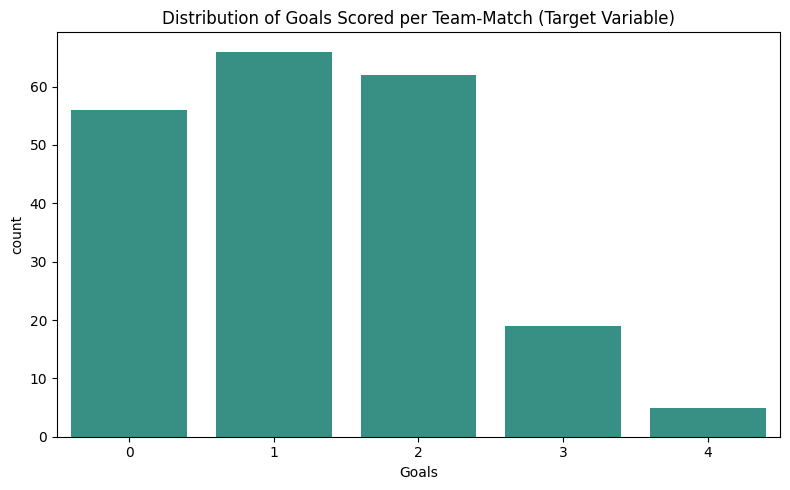

In [ ]:
print("Target variable (Goals) distribution:")
print(df['Goals'].value_counts().sort_index())
print(f"\nMean goals per team-match: {df['Goals'].mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='Goals', data=df, color='#2a9d8f', ax=ax)
ax.set_title('Distribution of Goals Scored per Team-Match (Target Variable)')
plt.tight_layout()
plt.show()

In [ ]:
# Collapse Stage into Group vs Knockout, several knockout sub stages (Third Place, Final)
# have only 1 match each (2 rows in long format), too sparse for a reliable per-category effect.
df['Stage_Group'] = np.where(df['Stage'] == 'Group Stage', 'Group Stage', 'Knockout')
print("Stage_Group counts:")
print(df['Stage_Group'].value_counts())


Stage_Group counts:
Stage_Group
Group Stage    144
Knockout        64
Name: count, dtype: int64


In [ ]:
# Turn Weather and Stage_Group into dummy variables (0/1 columns), same as pd.get_dummies()
df_encoded = pd.get_dummies(df, columns=['Weather', 'Stage_Group'], drop_first=True)

feature_cols = ['xG', 'Possession', 'Shots', 'Shots_On_Target', 'Corners',
                 'Fouls', 'Yellow_Cards', 'Rank_Advantage'] + \
               [c for c in df_encoded.columns if c.startswith('Weather_') or c.startswith('Stage_Group_')]

print("Final feature columns:")
print(feature_cols)

X = df_encoded[feature_cols].copy()
y = df_encoded['Goals'].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)
X.head()

Final feature columns:
['xG', 'Possession', 'Shots', 'Shots_On_Target', 'Corners', 'Fouls', 'Yellow_Cards', 'Rank_Advantage', 'Weather_Partly Cloudy', 'Weather_Rainy', 'Weather_Sunny', 'Stage_Group_Knockout']

X shape: (208, 12)
y shape: (208,)


,xG,Possession,Shots,Shots_On_Target,Corners,Fouls,Yellow_Cards,Rank_Advantage,Weather_Partly Cloudy,Weather_Rainy,Weather_Sunny,Stage_Group_Knockout
0,1.24,35,13,6,4,9,5,-33,False,False,True,False
1,1.57,42,10,3,9,18,3,8,False,True,False,False
2,2.43,41,7,1,2,17,2,-8,False,False,True,False
3,0.98,52,9,1,10,11,0,-19,False,False,True,False
4,1.55,49,11,5,3,16,5,-7,False,False,False,False


In [ ]:
#train the model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (166, 12)
X_test shape:  (42, 12)
y_train shape: (166,)
y_test shape:  (42,)


In [ ]:
scaler = StandardScaler()

# Fit on training data ONLY, then apply the same transformation to both sets
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# transform() returns a numpy array - convert back to a DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Before scaling (X_train, first 3 rows):")
print(X_train[['xG', 'Possession']].head(3))
print("\nAfter scaling (X_train_scaled, first 3 rows):")
print(X_train_scaled[['xG', 'Possession']].head(3))


Before scaling (X_train, first 3 rows):
       xG  Possession
86   0.64          39
203  1.78          61
67   1.98          65

After scaling (X_train_scaled, first 3 rows):
           xG  Possession
86  -0.937847   -1.260306
203  0.716036    1.263070
67   1.006190    1.721865


In [ ]:
baseline_prediction = y_train.mean()
baseline_pred_array = np.full(shape=y_test.shape, fill_value=baseline_prediction)

baseline_mae = mean_absolute_error(y_test, baseline_pred_array)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_array))
baseline_r2 = r2_score(y_test, baseline_pred_array)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression:")
print(f"  MAE:  {lr_mae:.3f}  (baseline: {baseline_mae:.3f})")
print(f"  RMSE: {lr_rmse:.3f}  (baseline: {baseline_rmse:.3f})")
print(f"  R²:   {lr_r2:.3f}")

Linear Regression:
  MAE:  0.590  (baseline: 0.798)
  RMSE: 0.748  (baseline: 0.940)
  R²:   0.350


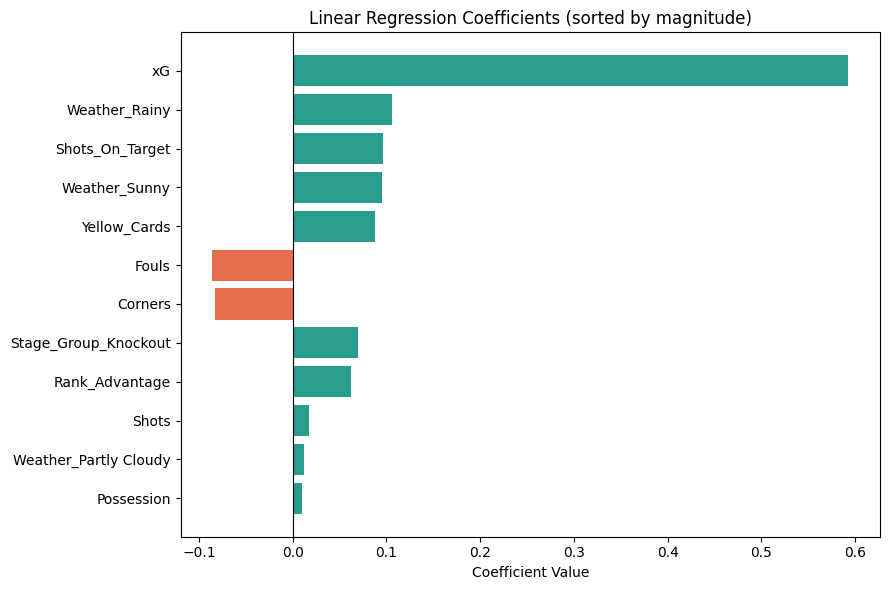

xG                       0.592761
Weather_Rainy            0.105948
Shots_On_Target          0.095884
Weather_Sunny            0.095473
Yellow_Cards             0.087343
Fouls                   -0.085705
Corners                 -0.082401
Stage_Group_Knockout     0.069755
Rank_Advantage           0.062480
Shots                    0.017834
Weather_Partly Cloudy    0.012117
Possession               0.010262
dtype: float64


In [ ]:
# Inspect coefficients to confirm xG dominance
coefs = pd.Series(lr_model.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2a9d8f' if c > 0 else '#e76f51' for c in coefs.values]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
ax.set_title('Linear Regression Coefficients (sorted by magnitude)')
ax.set_xlabel('Coefficient Value')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print(coefs)


**Confirms the EDA finding:** `xG` has by far the largest coefficient. Everything else is small by comparison consistent with xG being the only feature carrying real predictive weight in this dataset.

**Note on scaling and tree models:** Random Forest, in the next section, does **not** need scaled features tree based models split on raw thresholds (e.g., "is xG > 1.2?"), so the scale of the input doesn't change how the tree splits. Scaling is only necessary here for Linear Regression's coefficients to be fairly comparable to each other. The Random Forest below is fit directly on the unscaled `X_train` / `X_test` for that reason.


In [ ]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=5,
                                  min_samples_leaf=4, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest:")
print(f"  MAE:  {rf_mae:.3f}  (baseline: {baseline_mae:.3f})")
print(f"  RMSE: {rf_rmse:.3f}  (baseline: {baseline_rmse:.3f})")
print(f"  R²:   {rf_r2:.3f}")


Random Forest:
  MAE:  0.605  (baseline: 0.798)
  RMSE: 0.740  (baseline: 0.940)
  R²:   0.363


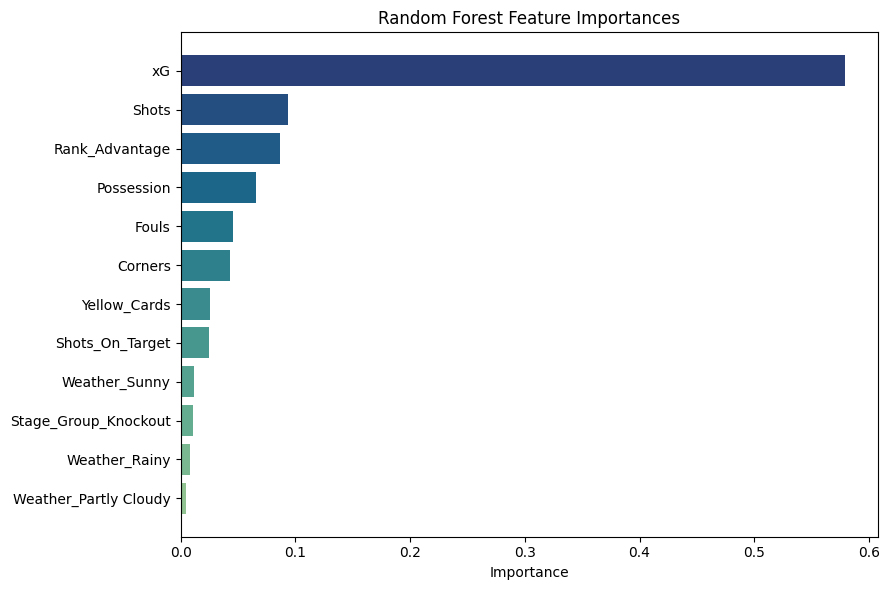

xG                       0.579166
Shots                    0.093228
Rank_Advantage           0.087012
Possession               0.065290
Fouls                    0.045860
Corners                  0.043213
Yellow_Cards             0.025491
Shots_On_Target          0.024956
Weather_Sunny            0.011948
Stage_Group_Knockout     0.010775
Weather_Rainy            0.008603
Weather_Partly Cloudy    0.004460
dtype: float64


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index[::-1], importances.values[::-1], color=sns.color_palette('crest', len(importances)))
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)


**Second confirmation:** the Random Forest's feature importance ranking independently agrees with the linear model's coefficients `xG` dominates, and the categorical/contextual features contribute almost nothing. Two different model families agreeing is a stronger signal than either alone.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Baseline (average)', 'Linear Regression', 'Random Forest'],
    'MAE': [baseline_mae, lr_mae, rf_mae],
    'RMSE': [baseline_rmse, lr_rmse, rf_rmse],
    'R2': [baseline_r2, lr_r2, rf_r2]
}).set_index('Model').round(3)

comparison['Improvement_vs_Baseline_MAE_%'] = ((baseline_mae - comparison['MAE']) / baseline_mae * 100).round(1)
comparison

,MAE,RMSE,R2,Improvement_vs_Baseline_MAE_%
Model,,,,
Baseline (average),0.798,0.940,-0.027,-0.0
Linear Regression,0.590,0.748,0.350,26.0
Random Forest,0.605,0.740,0.363,24.2


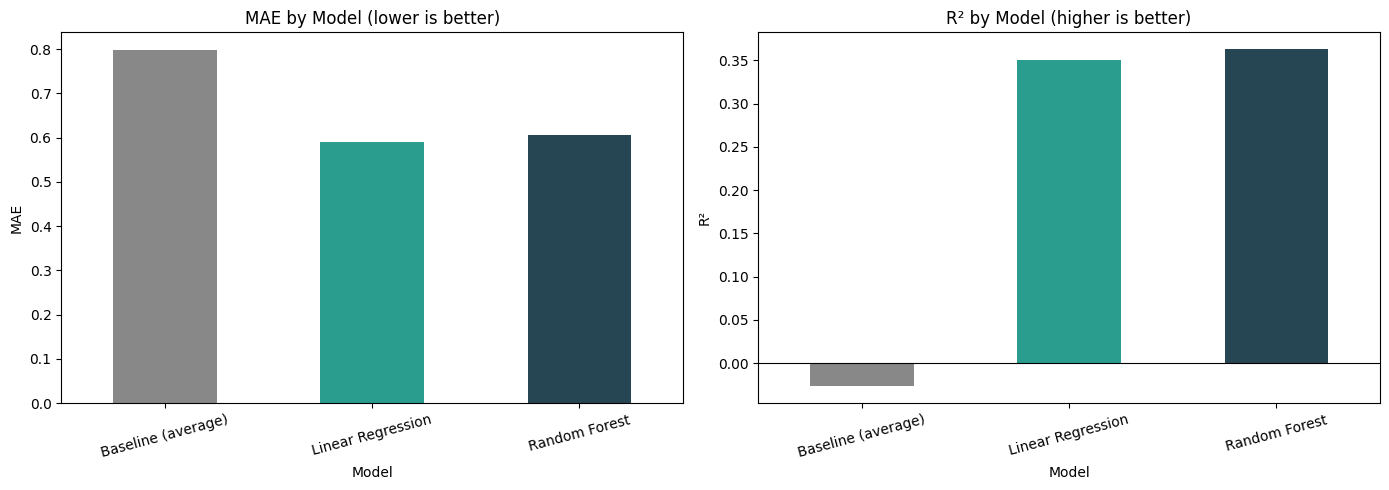

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison['MAE'].plot(kind='bar', ax=axes[0], color=['#888888','#2a9d8f','#264653'])
axes[0].set_title('MAE by Model (lower is better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

comparison['R2'].plot(kind='bar', ax=axes[1], color=['#888888','#2a9d8f','#264653'])
axes[1].set_title('R² by Model (higher is better)')
axes[1].set_ylabel('R²')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


In [ ]:
# Pick the best model by test-set MAE for diagnostic plots
if lr_mae <= rf_mae:
    best_model_name, best_pred = 'Linear Regression', lr_pred
else:
    best_model_name, best_pred = 'Random Forest', rf_pred

print(f"Best model by test set MAE: {best_model_name}")


Best model by test set MAE: Linear Regression


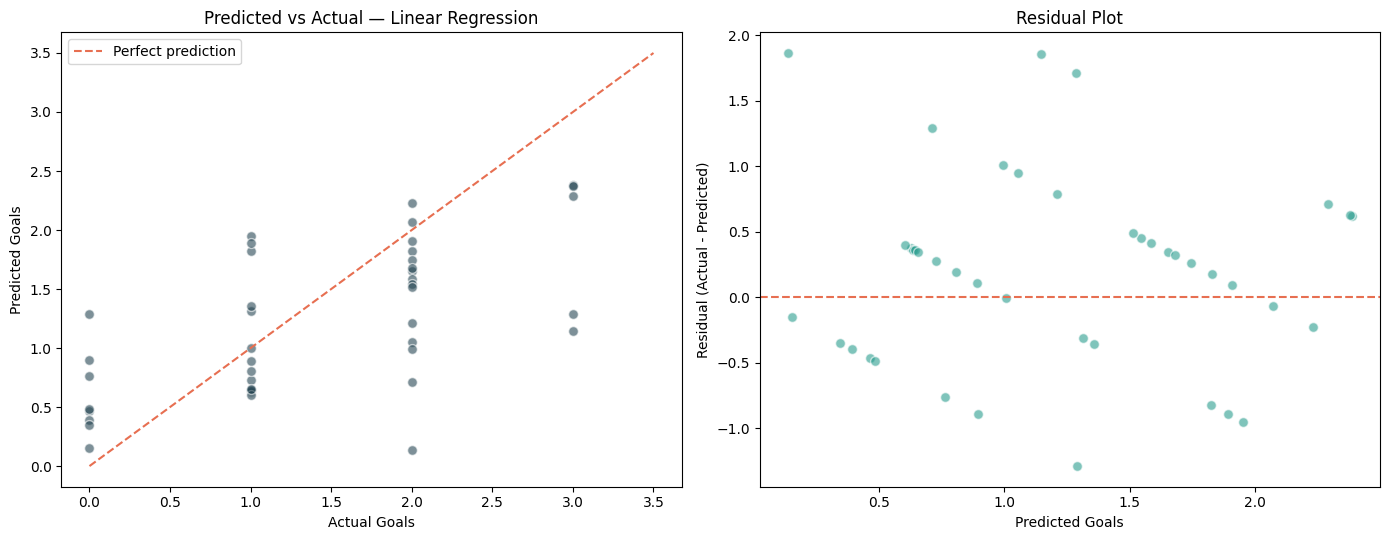

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Predicted vs Actual
axes[0].scatter(y_test, best_pred, alpha=0.6, s=50, color='#264653', edgecolor='white')
lims = [0, max(y_test.max(), best_pred.max()) + 0.5]
axes[0].plot(lims, lims, '--', color='#e76f51', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Goals')
axes[0].set_ylabel('Predicted Goals')
axes[0].set_title(f'Predicted vs Actual — {best_model_name}')
axes[0].legend()

# Residuals
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.6, s=50, color='#2a9d8f', edgecolor='white')
axes[1].axhline(0, color='#e76f51', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Goals')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


**Reading the residual plot honestly:** residuals show no strong funnel or curve pattern, which is good (no obvious heteroscedasticity), but they're wide relative to the prediction range expected, given goals scored has real randomness even when xG is known (a team can rack up high xG and still not finish chances). The model captures the *signal* xG provides; it can't capture finishing variance, because no feature in this dataset encodes that.

## Interpretation & Limitations

**What the model demonstrates:**
- Both real models beat the baseline on MAE, confirming `xG` does carry usable predictive signal for goals scored this isn't a complete null result.
- Linear Regression and Random Forest converge on the same conclusion:
- **xG explains the goal scoring signal in this dataset almost on its own.** Random Forest's feature importances and Linear Regression's coefficients agree with each other and with the EDA correlation analysis three independent forms of evidence pointing the same direction is more credible than any one of them alone.

**Why R² is modest (and why that's the honest result, not a failure):**
- An R² roughly in the 0.2 to 0.4 range is expected given the EDA finding that almost every feature *besides* xG is uncorrelated with goals. A model can't extract signal that isn't in the input features.
- A higher R² would actually be a red flag here it would suggest the model is fitting noise from a 208 row dataset rather than a genuine relationship.

**Limitations to state explicitly:**
1. **Sample size:** 208 team match rows is small for a Random Forest; results would benefit from more data or simpler models in production.
2. **Single train/test split:** with only ~42 rows in the test set, this comparison is reasonable for a portfolio piece but a different random split could shift the exact numbers somewhat worth keeping in mind rather than treating any single decimal point as precise.
3. **Synthetic data:** as documented in the EDA notebook, FIFA rank shows ~0 correlation with outcomes here a real world model would expect rank, recent form, and head to head history to matter, none of which are reliably present in this dataset.
4. **xG circularity:** xG is itself a model generated estimate of goal scoring chances, so "xG predicts goals well" is a partially expected, partially circular finding it's encouraging that the relationship holds, but it's not the same as predicting goals purely from raw match events.
5. **No live deployment context:** this model predicts goals using in-match stats (shots, possession, xG) that are only fully known *during or after* the match it's an explanatory model of what relates to goals, not a pre-match forecasting tool. A genuinely predictive (pre-match) model would need to drop `Shots`/`Possession`/`xG` and rely on historical team form instead, which isn't available in this dataset.
